# Step-by-Step JSCC Simulation for Semantic Meaning

In traditional systems, Source Coding (compressing data) and Channel Coding (adding redundancy to fight noise) are two separate steps. In **Joint Source-Channel Coding (JSCC)**, we map the input directly into a continuous latent space that is inherently robust to noise. 

This notebook provides a sample simulation using `Sentence-BERT` as our neural transmitter and receiver. We will execute this step-by-step.

### Step 1: The Transmitter (Source Coding)
First, we load an embedding model. This model converts discrete text into dense, high-dimensional vectors. This is our semantic compression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

print("wait...")
model = SentenceTransformer('all-MiniLM-L6-v2')

wait...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Step 2: The Receiver's Knowledge Base
The receiver needs to know the "language" or vocabulary of possible meanings. We pre-compute vectors for a small set of phrases.just for a mini simulation

In [2]:
knowledge_base = [
    "i am a software developer",
    "i am a student",
    "i want to confess to aadz , done chasing",
    "im typing anything random",
    "i lost my mind , no one noticed"
]

#pre-computation
kb_embeddings = model.encode(knowledge_base, convert_to_numpy=True)
print(f"{len(knowledge_base)} sentences.")
print(f"{kb_embeddings.shape[1]}-dimensional vector.")

5 sentences.
384-dimensional vector.


### Step 3: Transmission
We select one message to transmit. We convert it into its mathematical vector representation `x`.

In [3]:
original_message = "i am tired chasing her"

x = model.encode(original_message, convert_to_numpy=True)

print(f"'{original_message}'")
print(f"x: {x[:5]}")

'i am tired chasing her'
x: [ 0.01843887 -0.05146488  0.04224952  0.01786325  0.09290905]


### Step 4: The Physical Channel (Noise Injection)
We simulate a physical wireless channel using Additive White Gaussian Noise (AWGN). We mathematically degrade the vector `x` to simulate interference, resulting in the noisy received signal `y`.

In [4]:

noise_std_dev = 0.1

# y = x + n
n = np.random.normal(0, noise_std_dev, size=x.shape)
y = x + n

print(f"y: {y[:5]}")

y: [-0.0212773  -0.05310671 -0.02738471  0.20881192  0.08533105]


### Visualization 1: Visualizing the Signal Distortion
Let's plot the first 50 dimensions of our semantic vector to see exactly what the channel noise did to our signal.

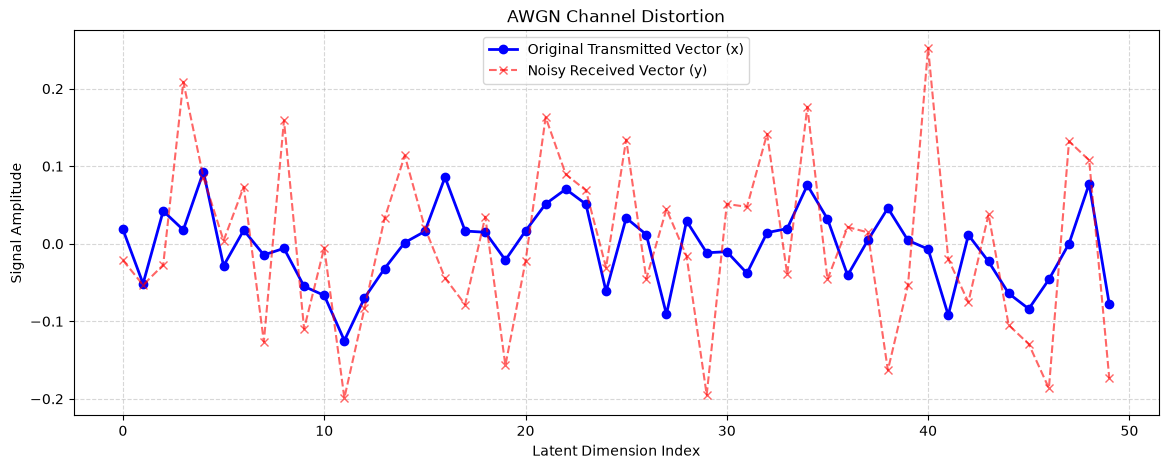

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(x[:50], label='Original Transmitted Vector (x)', color='blue', linewidth=2, marker='o')
plt.plot(y[:50], label='Noisy Received Vector (y)', color='red', alpha=0.6, linestyle='dashed', marker='x')

plt.title("AWGN Channel Distortion")
plt.xlabel("Latent Dimension Index")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 5: The Receiver (Semantic Decoding)
The receiver gets the noisy vector `y`. it uses **Cosine Similarity** to find the closest semantic match in its Knowledge Base.

In [6]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

similarities = []
for i, kb_vec in enumerate(kb_embeddings):
    sim = cosine_similarity(y, kb_vec)
    similarities.append((knowledge_base[i], sim))

similarities.sort(key=lambda item: item[1], reverse=True)


for phrase, score in similarities:
    print(f"Score: {score:.4f} | Phrase: '{phrase}'")


print(f"prediction '{similarities[0][0]}'")


Score: 0.2587 | Phrase: 'i want to confess to aadz , done chasing'
Score: 0.0609 | Phrase: 'i lost my mind , no one noticed'
Score: 0.0534 | Phrase: 'i am a student'
Score: 0.0351 | Phrase: 'i am a software developer'
Score: 0.0310 | Phrase: 'im typing anything random'
prediction 'i want to confess to aadz , done chasing'


### Visualization 2: Semantic Decoding Confidence

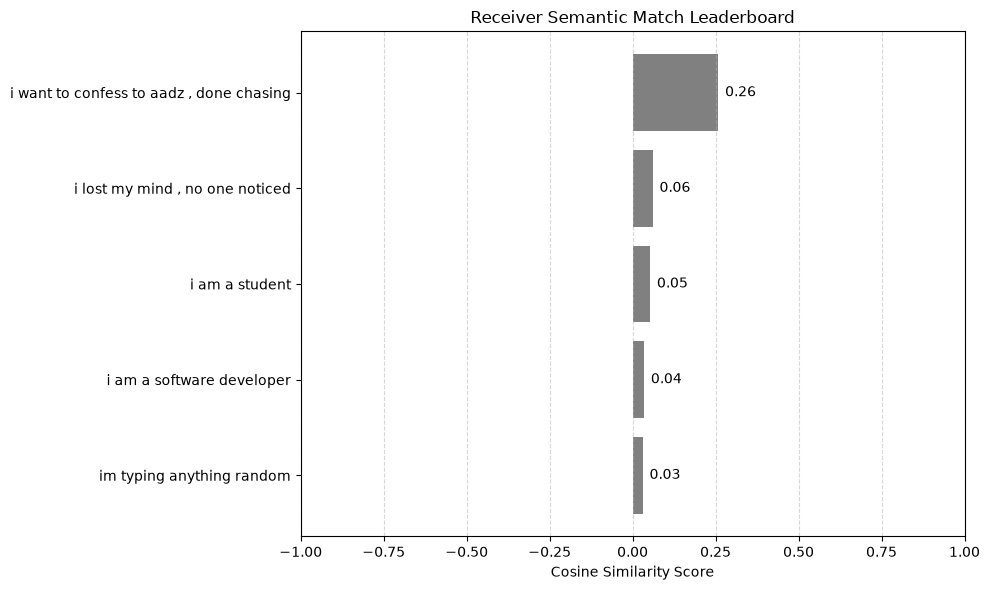

In [7]:
phrases = [item[0] for item in similarities]
scores = [item[1] for item in similarities]

phrases.reverse()
scores.reverse()

plt.figure(figsize=(10, 6))
colors = ['green' if phrase == original_message else 'gray' for phrase in phrases]

bars = plt.barh(phrases, scores, color=colors)

plt.xlabel("Cosine Similarity Score")
plt.title("Receiver Semantic Match Leaderboard")
plt.xlim(-1.0, 1.0)  
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}', 
             va='center', ha='left', color='black')

plt.tight_layout()
plt.show()